In [2]:
import pandas as pd
df=pd.read_csv('18.tmdb_5000_movies.csv')
print("前3行")
print(df.head(3))
print("后2行")
print(df.tail(2))

前3行
      budget                                             genres  \
0  237000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   
1  300000000  [{"id": 12, "name": "Adventure"}, {"id": 14, "...   
2  245000000  [{"id": 28, "name": "Action"}, {"id": 12, "nam...   

                                       homepage      id  \
0                   http://www.avatarmovie.com/   19995   
1  http://disney.go.com/disneypictures/pirates/     285   
2   http://www.sonypictures.com/movies/spectre/  206647   

                                            keywords original_language  \
0  [{"id": 1463, "name": "culture clash"}, {"id":...                en   
1  [{"id": 270, "name": "ocean"}, {"id": 726, "na...                en   
2  [{"id": 470, "name": "spy"}, {"id": 818, "name...                en   

                             original_title  \
0                                    Avatar   
1  Pirates of the Caribbean: At World's End   
2                                   Spectre   

    

In [12]:
import pandas as pd
df=pd.read_csv('18.tmdb_5000_movies.csv')
selected_columns=['id','release_date','title','vote_average','vote_count']
df=df[selected_columns]
df=df.dropna()
df.to_csv('tmdb_5000_movies_vote.csv',index=False)

In [14]:
import pandas as pd
df=pd.read_csv('tmdb_5000_movies_vote.csv')
df=df.sort_values(by='vote_average',ascending=False)
df.to_csv('tmdb_5000_movies_vote_descending.txt',index=False,sep=',')

In [17]:
import pandas as pd
df=pd.read_csv('tmdb_5000_movies_vote_descending.txt',sep=',')
vote_average=df['vote_average']
maxValue=vote_average.max()
minValue=vote_average.min()
meanValue=vote_average.mean()
print(f"最大值:{maxValue}")
print(f"最小值:{minValue}")
print(f"平均值:{meanValue}")

最大值:10.0
最小值:0.0
平均值:6.093440233236151


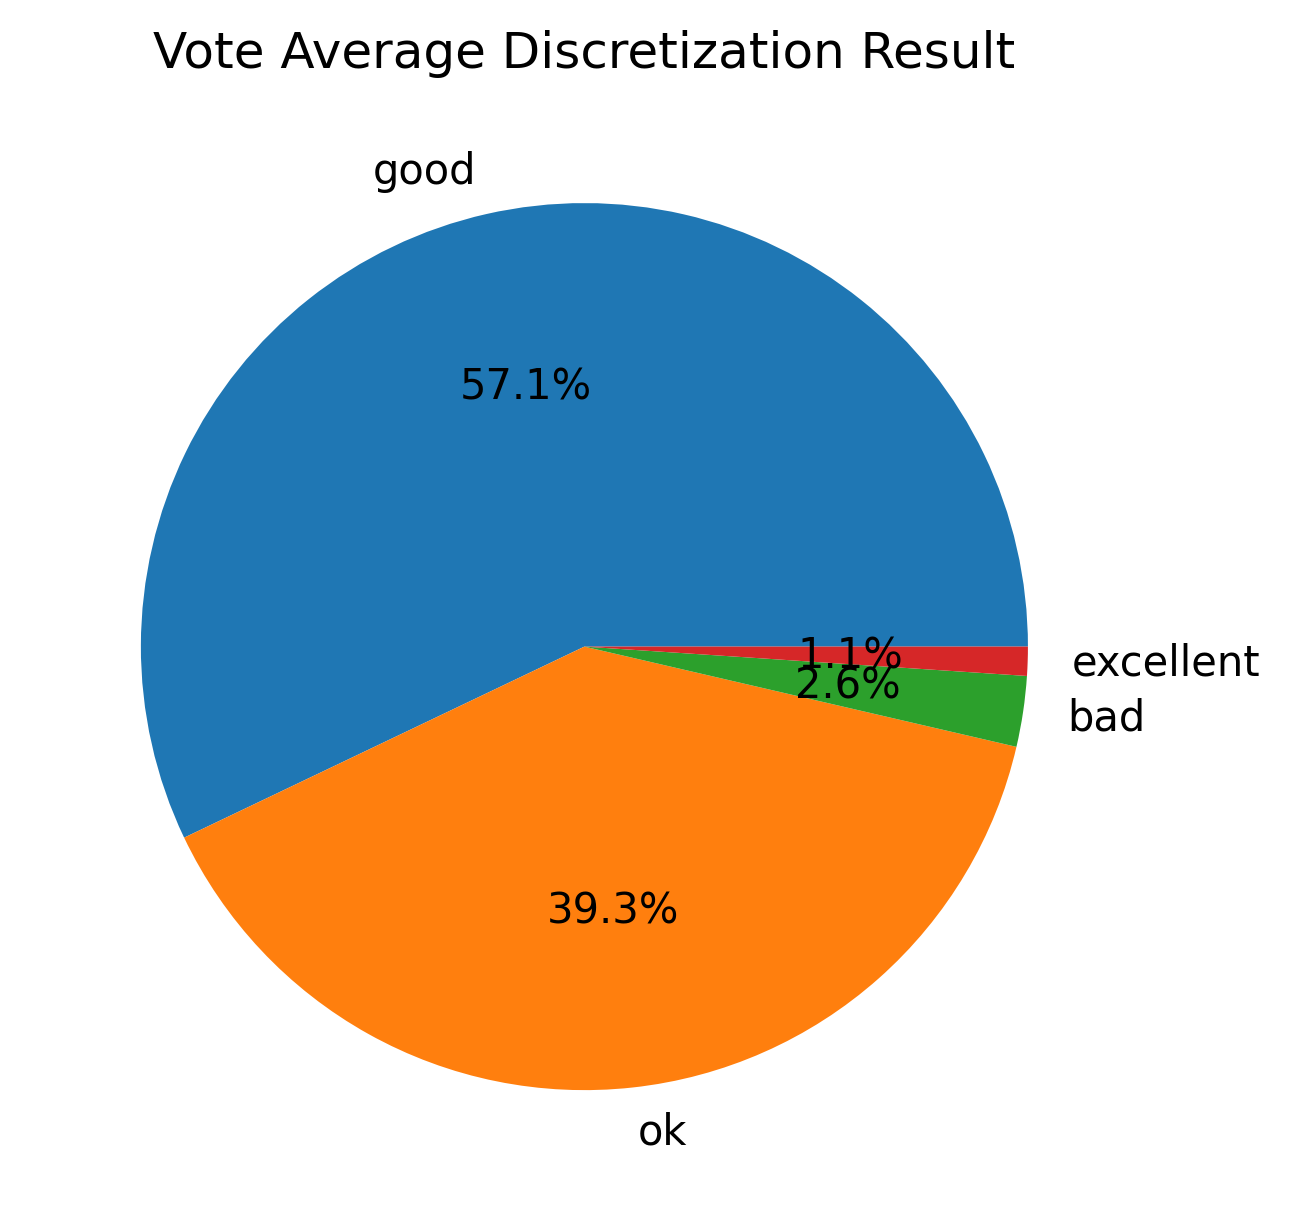

In [21]:
import matplotlib.pyplot as plt
new_df=pd.read_csv('tmdb_5000_movies_vote_descending.txt',sep=',')
category=[minValue,4,6,8,maxValue]
labels=['bad','ok','good','excellent']
new_df['Label']=pd.cut(new_df['vote_average'],bins=category,labels=labels)
new_df.to_csv('tmdb_5000_movies_vote_descending_result.csv',index=False)
label_counts=new_df['Label'].value_counts()
plt.figure(dpi=300)
plt.pie(label_counts,labels=label_counts.index,autopct='%1.1f%%')
plt.title('Vote Average Discretization Result')
plt.savefig('tmdb_5000_movies_vote_descending_result_pie.png')
plt.show()